In [ ]:
import pandas as pd
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import tensorflow as tf
tf.get_logger().setLevel("ERROR")


# Charger le CSV
df = pd.read_csv("../../data/dataset_selection_sans_leger.csv")

# Aperçu du dataset
print("Aperçu du dataset :")
print(df.head())

print("\nInformations générales :")
print(df.info())


Aperçu du dataset :
                                                path     label
0  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome
1  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome
2  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tes...  glaucome
3  /home/mathis/Memoire/data/glaucome/ORIGA/ORIGA...  glaucome
4  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tes...  glaucome

Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6208 entries, 0 to 6207
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   path    6208 non-null   object
 1   label   6208 non-null   object
dtypes: object(2)
memory usage: 97.1+ KB
None


In [2]:
print(f"Nombre total d'images : {len(df)}")
print(f"Nombre de colonnes : {df.shape[1]}")


Nombre total d'images : 6208
Nombre de colonnes : 2


In [3]:
# Compter le nombre d'images par label
class_counts = df['label'].value_counts()

print("\nRépartition des labels :")
print(class_counts)

# Pourcentage par label
class_percent = df['label'].value_counts(normalize=True) * 100
print("\nPourcentage par label :")
print(class_percent.round(2))



Répartition des labels :
label
glaucome    1552
mda         1552
diabete     1552
normaux     1552
Name: count, dtype: int64

Pourcentage par label :
label
glaucome    25.0
mda         25.0
diabete     25.0
normaux     25.0
Name: proportion, dtype: float64


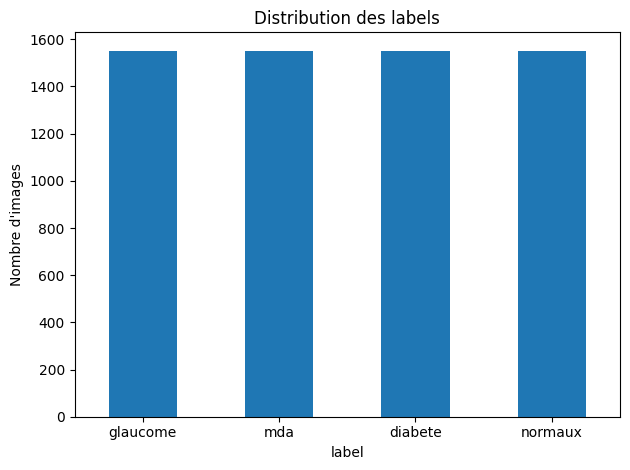

In [4]:
import matplotlib.pyplot as plt

class_counts.plot(kind='bar')
plt.title("Distribution des labels")
plt.xlabel("label")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [5]:
for classe in df['label'].unique():
    print(f"\nExemples pour la classe '{classe}' :")
    print(df[df['label'] == classe]['path'].head(3).tolist())



Exemples pour la classe 'glaucome' :
['/home/mathis/Memoire/data/glaucome/LAG/LAG/Training/glaucoma/1308.jpg', '/home/mathis/Memoire/data/glaucome/LAG/LAG/Training/glaucoma/1456.jpg', '/home/mathis/Memoire/data/glaucome/LAG/LAG/Testing/glaucoma/4275.jpg']

Exemples pour la classe 'mda' :
['/home/mathis/Memoire/data/mda/Fundus/Fundus/ARMD/161.png', '/home/mathis/Memoire/data/mda/Fundus/Fundus/ARMD/328.png', '/home/mathis/Memoire/data/mda/Fundus/Fundus/ARMD/235.png']

Exemples pour la classe 'diabete' :
['/home/mathis/Memoire/data/diabete/train.zip/train/25985_right.jpeg', '/home/mathis/Memoire/data/diabete/train.zip/train/38016_right.jpeg', '/home/mathis/Memoire/data/diabete/train.zip/train/20574_left.jpeg']

Exemples pour la classe 'normaux' :
['/home/mathis/Memoire/data/mda/ODIR-5K/ODIR-5K/Training Images/2457_right.jpg', '/home/mathis/Memoire/data/diabete/train.zip/train/30306_left.jpeg', '/home/mathis/Memoire/data/diabete/train.zip/train/3710_left.jpeg']


In [6]:
from sklearn.model_selection import train_test_split

df_train, df_temp = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

df_test, df_val = train_test_split(
    df_temp,
    test_size=0.5,
    stratify=df_temp['label'],
    random_state=42
)

print("Tailles des splits :")
print(f"Train : {len(df_train)}")
print(f"Test : {len(df_test)}")
print(f"Validation : {len(df_val)}")

Tailles des splits :
Train : 4966
Test : 621
Validation : 621


In [7]:
def show_distribution(name, data):
    print(f"\n{name}")
    print(data['label'].value_counts(normalize=True).round(3))

show_distribution("Train", df_train)
show_distribution("Test", df_test)
show_distribution("Validation", df_val)



Train
label
glaucome    0.25
normaux     0.25
mda         0.25
diabete     0.25
Name: proportion, dtype: float64

Test
label
mda         0.251
glaucome    0.250
diabete     0.250
normaux     0.250
Name: proportion, dtype: float64

Validation
label
diabete     0.251
glaucome    0.250
normaux     0.250
mda         0.250
Name: proportion, dtype: float64


In [8]:
import sys, torch
print(sys.executable)
print(torch.__version__)
import torch
print(torch.__version__)
print("cuda available:", torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

x = torch.randn(1000, 1000, device="cuda")
print("OK:", x.mean().item())


/home/mathis/Memoire/.venv/bin/python
2.5.1+cu121
2.5.1+cu121
cuda available: True
NVIDIA GeForce RTX 3070 Ti
OK: 0.0005666771321557462


In [9]:
# =========================
# PyTorch pipeline COMPLET
# ResNet34 pré-entraîné + crop + class weights + label smoothing + dropout
# + AMP + AdamW + ReduceLROnPlateau + EarlyStopping + fine-tuning 2 phases
# =========================

import os, numpy as np
from collections import Counter
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.amp import autocast, GradScaler

IMG         = 224
BATCH       = 32
EPOCHS_P1   = 10    # Phase 1 : backbone gelé
EPOCHS_P2   = 300   # Phase 2 : backbone dégelé
PATIENCE    = 20
NUM_WORKERS = 4

# -------------------------------------------------
# 0) Device
# -------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -------------------------------------------------
# 1) Crop des bordures noires
# -------------------------------------------------
def crop_black_border_pil(img: Image.Image, thr: int = 10, pad: int = 10) -> Image.Image:
    arr  = np.array(img)
    gray = arr.mean(axis=2)
    mask = gray > thr
    if not mask.any():
        return img
    ys, xs = np.where(mask)
    y0 = max(0, ys.min() - pad)
    y1 = min(arr.shape[0] - 1, ys.max() + pad)
    x0 = max(0, xs.min() - pad)
    x1 = min(arr.shape[1] - 1, xs.max() + pad)
    return img.crop((x0, y0, x1 + 1, y1 + 1))

# -------------------------------------------------
# 2) Transforms
# -------------------------------------------------
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

eval_tfms = transforms.Compose([
    transforms.Resize(IMG+32),
    transforms.CenterCrop(IMG),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

# -------------------------------------------------
# 3) Dataset avec crop intégré
# -------------------------------------------------
class FromSamples(Dataset):
    def __init__(self, paths, labels, transform=None, do_crop=True):
        self.paths     = np.array(paths)
        self.labels    = np.array(labels)
        self.transform = transform
        self.do_crop   = do_crop

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        if self.do_crop:
            img = crop_black_border_pil(img, thr=10, pad=10)
        if self.transform is not None:
            img = self.transform(img)
        return img, int(self.labels[i])

# --- Vérif colonnes ---
for name, d in [("df_train", df_train), ("df_val", df_val), ("df_test", df_test)]:
    assert "path" in d.columns and "label" in d.columns

# --- Remap labels -> {0..C-1} ---
orig_classes = sorted(df_train["label"].unique().tolist())
label_map    = {c: i for i, c in enumerate(orig_classes)}
print("Label mapping:", label_map)

df_train = df_train.copy(); df_train["label"] = df_train["label"].map(label_map)
df_val   = df_val.copy();   df_val["label"]   = df_val["label"].map(label_map)
df_test  = df_test.copy();  df_test["label"]  = df_test["label"].map(label_map)

ds_train = FromSamples(df_train["path"].values, df_train["label"].values, train_tfms, do_crop=True)
ds_val   = FromSamples(df_val["path"].values,   df_val["label"].values,   eval_tfms,  do_crop=True)
ds_test  = FromSamples(df_test["path"].values,  df_test["label"].values,  eval_tfms,  do_crop=True)

train_loader = DataLoader(ds_train, batch_size=BATCH, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(ds_val,   batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(ds_test,  batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# -------------------------------------------------
# 4) Class weights
# -------------------------------------------------
cnt = Counter(df_train["label"].values.tolist())
num_classes = len(orig_classes)
print("Train counts:", cnt)

weights_list = [
    len(df_train) / (num_classes * cnt[c]) if cnt.get(c, 0) > 0 else 1.0
    for c in range(num_classes)
]
weights_ce = torch.tensor(weights_list, dtype=torch.float32, device=device)
print("Class weights:", [round(w, 4) for w in weights_list])

# -------------------------------------------------
# 5) Modèle : ResNet34 + Dropout + tête FC
# -------------------------------------------------
weights_pretrained = models.ResNet34_Weights.IMAGENET1K_V1
model = models.resnet34(weights=weights_pretrained)
# Remplace la FC par : Dropout(0.3) → Linear
model.fc = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(model.fc.in_features, num_classes),
)
model = model.to(device)

# Label smoothing intégré dans la loss
criterion = nn.CrossEntropyLoss(weight=weights_ce, label_smoothing=0.1)
scaler    = GradScaler("cuda")

# -------------------------------------------------
# 6) Utilitaires
# -------------------------------------------------
@torch.no_grad()
def evaluate(loader):
    model.eval()
    loss_sum, correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        with autocast("cuda"):
            logits = model(x)
            loss   = criterion(logits, y)
        loss_sum += loss.item() * x.size(0)
        correct  += (logits.argmax(1) == y).sum().item()
        n        += x.size(0)
    return loss_sum / max(n, 1), correct / max(n, 1)

def run_phase(epochs, lr, freeze_backbone, patience, label):
    """Lance une phase d'entraînement. Retourne (best_acc, best_state)."""
    # Gel / dégel du backbone
    for name, param in model.named_parameters():
        param.requires_grad = (not freeze_backbone) or ("fc" in name)

    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n{'='*60}")
    print(f"{label}  |  lr={lr}  |  params entraînables : {n_trainable:,}")
    print(f"{'='*60}")

    optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                      lr=lr, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=10)

    best_acc, best_state, wait = 0.0, None, 0

    for epoch in range(1, epochs + 1):
        model.train()
        run_loss, n = 0.0, 0
        for x, y in train_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with autocast("cuda"):
                logits = model(x)
                loss   = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            run_loss += loss.item() * x.size(0)
            n        += x.size(0)

        train_loss = run_loss / max(n, 1)
        val_loss, val_acc = evaluate(val_loader)
        scheduler.step(val_acc)

        lr_cur = optimizer.param_groups[0]["lr"]
        print(f"  Epoch {epoch:03d} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f} | val_acc {val_acc:.4f} | lr {lr_cur:.2e}")

        if val_acc > best_acc:
            best_acc   = val_acc
            wait       = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stopping à l'epoch {epoch} (best val_acc={best_acc:.4f})")
                break

    return best_acc, best_state

# -------------------------------------------------
# 7) Phase 1 : backbone gelé, tête seule
# -------------------------------------------------
best_acc_p1, best_state_p1 = run_phase(
    epochs=EPOCHS_P1, lr=1e-3,
    freeze_backbone=True, patience=EPOCHS_P1,  # pas d'early stop en phase 1
    label="PHASE 1 — backbone gelé, tête FC uniquement"
)

# -------------------------------------------------
# 8) Phase 2 : tout dégelé, lr plus faible
# -------------------------------------------------
best_acc_p2, best_state_p2 = run_phase(
    epochs=EPOCHS_P2, lr=1e-4,
    freeze_backbone=False, patience=PATIENCE,
    label="PHASE 2 — backbone dégelé, fine-tuning complet"
)

# Charger le meilleur état (phase 2)
model.load_state_dict(best_state_p2)
print(f"\nMeilleur modèle rechargé — val_acc phase 2 = {best_acc_p2:.4f}")


Device: cuda
Label mapping: {'diabete': 0, 'glaucome': 1, 'mda': 2, 'normaux': 3}
Train counts: Counter({1: 1242, 3: 1242, 2: 1241, 0: 1241})
Class weights: [1.0004, 0.9996, 1.0004, 0.9996]

PHASE 1 — backbone gelé, tête FC uniquement  |  lr=0.001  |  params entraînables : 2,052
  Epoch 001 | train_loss 1.0656 | val_loss 0.9594 | val_acc 0.6522 | lr 1.00e-03
  Epoch 002 | train_loss 0.9554 | val_loss 0.9476 | val_acc 0.6538 | lr 1.00e-03
  Epoch 003 | train_loss 0.9064 | val_loss 0.8879 | val_acc 0.6812 | lr 1.00e-03
  Epoch 004 | train_loss 0.9143 | val_loss 0.8863 | val_acc 0.6973 | lr 1.00e-03
  Epoch 005 | train_loss 0.9159 | val_loss 0.8592 | val_acc 0.7118 | lr 1.00e-03
  Epoch 006 | train_loss 0.9074 | val_loss 0.8502 | val_acc 0.7021 | lr 1.00e-03
  Epoch 007 | train_loss 0.8907 | val_loss 0.8607 | val_acc 0.7085 | lr 1.00e-03
  Epoch 008 | train_loss 0.8952 | val_loss 0.8524 | val_acc 0.7214 | lr 1.00e-03
  Epoch 009 | train_loss 0.8872 | val_loss 0.8744 | val_acc 0.7037 | lr 


=== Scores globaux (avec TTA) ===
Accuracy            : 0.8583
Balanced accuracy   : 0.8582
Precision (macro)   : 0.8693
Recall    (macro)   : 0.8582
F1        (macro)   : 0.8562
F1        (weighted): 0.8563

=== Rapport par classe ===
              precision    recall  f1-score   support

     diabete       0.95      0.79      0.86       155
    glaucome       0.76      1.00      0.86       155
         mda       0.91      0.93      0.92       156
     normaux       0.86      0.71      0.78       155

    accuracy                           0.86       621
   macro avg       0.87      0.86      0.86       621
weighted avg       0.87      0.86      0.86       621



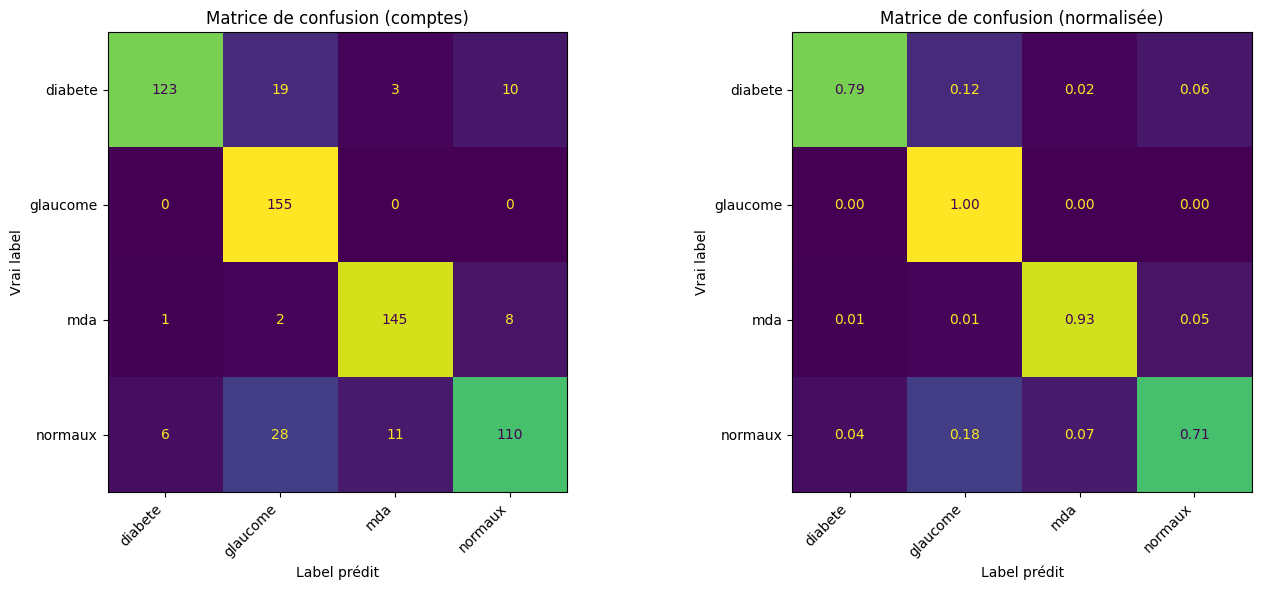

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    classification_report
)
from torch.amp import autocast

# -------------------------------------------------
# Test Time Augmentation (TTA)
# On fait N passes avec des augmentations légères et on moyenne les probas
# -------------------------------------------------
tta_tfms = [
    eval_tfms,  # passe sans augmentation (originale)
    transforms.Compose([
        transforms.Resize(IMG+32), transforms.CenterCrop(IMG),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ]),
    transforms.Compose([
        transforms.Resize(IMG+32), transforms.CenterCrop(IMG),
        transforms.RandomVerticalFlip(p=1.0),
        transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ]),
    transforms.Compose([
        transforms.Resize(IMG+32), transforms.CenterCrop(IMG),
        transforms.RandomRotation((90, 90)),
        transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ]),
    transforms.Compose([
        transforms.Resize(IMG+32), transforms.CenterCrop(IMG),
        transforms.RandomRotation((-90, -90)),
        transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ]),
]

model.eval()
all_y = []

# Accumulateur de probas pour la TTA
tta_proba_sum = None

for tfm in tta_tfms:
    ds_tta  = FromSamples(df_test["path"].values, df_test["label"].values, tfm, do_crop=True)
    ld_tta  = DataLoader(ds_tta, batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    batch_proba, batch_y = [], []
    with torch.no_grad():
        for x, y in ld_tta:
            x = x.to(device, non_blocking=True)
            with autocast("cuda"):
                logits = model(x)
            proba = torch.softmax(logits, dim=1).cpu().numpy()
            batch_proba.append(proba)
            batch_y.append(y.numpy())
    proba_arr = np.concatenate(batch_proba, axis=0)
    if tta_proba_sum is None:
        tta_proba_sum = proba_arr
        all_y = np.concatenate(batch_y, axis=0)
    else:
        tta_proba_sum += proba_arr

y_proba = tta_proba_sum / len(tta_tfms)
y_true  = all_y
y_pred  = y_proba.argmax(axis=1)

classes      = orig_classes
num_classes  = len(classes)
target_names = [str(c) for c in classes]

print("\n=== Scores globaux (avec TTA) ===")
print(f"Accuracy            : {accuracy_score(y_true, y_pred):.4f}")
print(f"Balanced accuracy   : {balanced_accuracy_score(y_true, y_pred):.4f}")
print(f"Precision (macro)   : {precision_score(y_true, y_pred, average='macro',    zero_division=0):.4f}")
print(f"Recall    (macro)   : {recall_score(   y_true, y_pred, average='macro',    zero_division=0):.4f}")
print(f"F1        (macro)   : {f1_score(       y_true, y_pred, average='macro',    zero_division=0):.4f}")
print(f"F1        (weighted): {f1_score(       y_true, y_pred, average='weighted', zero_division=0):.4f}")

print("\n=== Rapport par classe ===")
print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))

# Matrices de confusion
label_indices = list(range(num_classes))
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, normalize, title in zip(
    axes,
    [None, "true"],
    ["Matrice de confusion (comptes)", "Matrice de confusion (normalisée)"],
):
    cm = confusion_matrix(y_true, y_pred, labels=label_indices, normalize=normalize)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(ax=ax, colorbar=False, values_format=".2f" if normalize else "d")
    ax.set_title(title)
    ax.set_xlabel("Label prédit")
    ax.set_ylabel("Vrai label")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()


Nombre d'images mal classées : 88


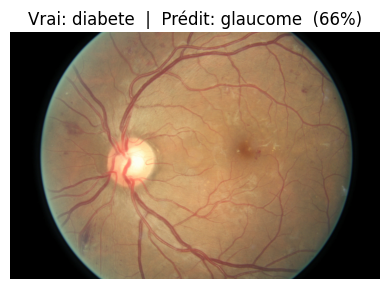

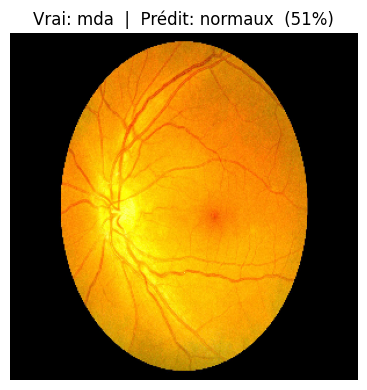

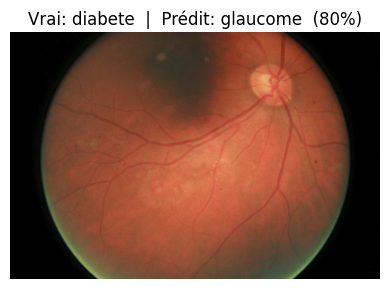

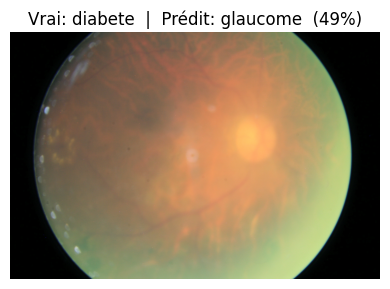

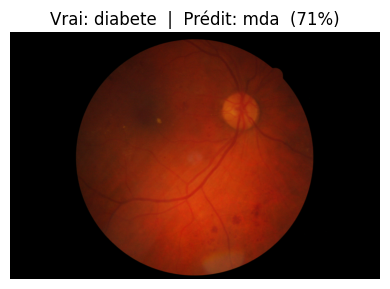

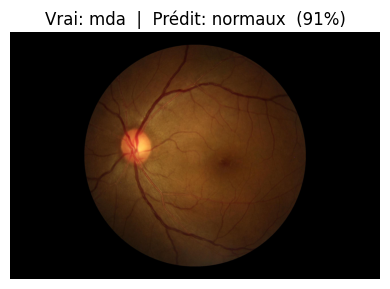

In [11]:
# Exemples d'images mal classées
import numpy as np
from PIL import Image

misclassified_indices = np.where(y_true != y_pred)[0]
print(f"Nombre d'images mal classées : {len(misclassified_indices)}")

for idx in misclassified_indices[:6]:
    img_path   = df_test.iloc[idx]['path']
    true_label = classes[y_true[idx]]
    pred_label = classes[y_pred[idx]]
    confidence = y_proba[idx][y_pred[idx]]

    img = Image.open(img_path).convert("RGB")
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"Vrai: {true_label}  |  Prédit: {pred_label}  ({confidence:.0%})")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
